![image 1](../images/image1.png)

![image 2](../images/image2.png)

![image 3](../images/image3.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/data.csv')
df.head()

,order_id,price,freight_value,payment_value,payment_installments,product_weight_g,customer_state,seller_state,customer_lat,customer_lng,seller_lat,seller_lng,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,delayed
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19,2.0,650.0,RJ,SP,-21.762775,-41.309633,-22.496953,-44.127492,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-29 00:00:00,0
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83,3.0,30000.0,SP,SP,-20.220527,-50.903424,-23.565096,-46.518565,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-15 00:00:00,0
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87,5.0,3050.0,MG,MG,-19.870305,-44.593326,-22.262584,-46.171124,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-02-05 00:00:00,0
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78,2.0,200.0,SP,SP,-23.089925,-46.611654,-20.553624,-47.387359,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-20 00:00:00,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04,3.0,3750.0,SP,PR,-23.243402,-46.827614,-22.929384,-53.135873,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-17 00:00:00,0


In [3]:
df.tail()

,order_id,price,freight_value,payment_value,payment_installments,product_weight_g,customer_state,seller_state,customer_lat,customer_lng,seller_lat,seller_lng,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,delayed
99436,fffc94f6ce00a00581880bf54a75a037,299.99,43.41,343.40,1.0,10150.0,MA,SC,-2.497993,-44.297761,-26.912574,-48.673980,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-18 00:00:00,0
99437,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,386.53,1.0,8950.0,PR,SP,-25.566904,-49.309115,-23.535864,-46.642819,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-08-01 00:00:00,0
99438,fffce4705a9662cd70adb13d4a31832d,99.90,16.95,116.85,3.0,967.0,SP,PR,-23.597794,-46.643923,-25.469955,-49.289821,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-11-10 00:00:00,0
99439,fffe18544ffabc95dfada21779c9644f,55.99,8.72,64.71,3.0,100.0,SP,SP,-23.040252,-46.979782,-23.635530,-46.694031,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-25 00:00:00,0
99440,fffe41c64501cc87c801fd61db3f6244,43.00,12.79,55.79,1.0,600.0,SP,SP,-22.916957,-48.441709,-21.757321,-48.829744,2018-06-09 17:00:18,2018-06-09 17:10:13,2018-06-11 14:11:00,2018-06-28 00:00:00,0


In [4]:
# Check for missing values and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  str    
 1   price                          99441 non-null  float64
 2   freight_value                  99441 non-null  float64
 3   payment_value                  99441 non-null  float64
 4   payment_installments           99440 non-null  float64
 5   product_weight_g               98650 non-null  float64
 6   customer_state                 99441 non-null  str    
 7   seller_state                   98666 non-null  str    
 8   customer_lat                   99163 non-null  float64
 9   customer_lng                   99163 non-null  float64
 10  seller_lat                     98450 non-null  float64
 11  seller_lng                     98450 non-null  float64
 12  order_purchase_timestamp       99441 non-null  str    
 1

## Insights
* order_purchase_timestamp -> Change to datetime
* order_approved_at -> Change to datetime
* order_delivered_carrier_date -> Change to datetime
* order_estimated_delivery_date -> Change to datetime

In [5]:
# Statistical summary of the dataset
df.describe()

,price,freight_value,payment_value,payment_installments,product_weight_g,customer_lat,customer_lng,seller_lat,seller_lng,delayed
count,99441.000000,99441.000000,99441.000000,99440.000000,98650.000000,99163.000000,99163.000000,98450.000000,98450.000000,99441.000000
mean,142.891265,23.706892,205.858013,2.930521,2103.175539,-21.191224,-46.175442,-22.793751,-47.220557,0.078710
std,240.560797,26.339293,619.118686,2.715685,3756.800238,5.608637,4.056067,2.750111,2.350226,0.269287
min,0.000000,0.000000,0.000000,0.000000,0.000000,-33.689948,-72.668881,-32.079231,-67.813284,0.000000
25%,45.900000,13.870000,62.760000,1.000000,300.000000,-23.589378,-48.097950,-23.612734,-48.784496,0.000000
50%,89.000000,17.440000,109.620000,2.000000,700.000000,-22.924970,-46.630647,-23.425556,-46.743468,0.000000
75%,152.000000,25.400000,195.910000,4.000000,1813.000000,-20.139828,-43.598897,-21.757321,-46.518679,0.000000
max,13440.000000,1897.760000,109312.640000,24.000000,40425.000000,42.184003,-8.723762,-2.501242,-34.855616,1.000000


* About 7.9% of all orders are delayed.
* Item prices have very extreme high maximum values.
* Most buyers use one to four payment installments.
* Product weights reach a maximum of forty kilograms.
* Some product prices and weights are exactly zero.

In [6]:
# Number of rows and columns
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 99441 rows and 17 columns.


In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Check for missing values
df.isnull().sum()

order_id                            0
price                               0
freight_value                       0
payment_value                       0
payment_installments                1
product_weight_g                  791
customer_state                      0
seller_state                      775
customer_lat                      278
customer_lng                      278
seller_lat                        991
seller_lng                        991
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_estimated_delivery_date       0
delayed                             0
dtype: int64

In [9]:
df['delayed'].value_counts()

delayed
0    91614
1     7827
Name: count, dtype: int64

Text(0, 0.5, 'Count')

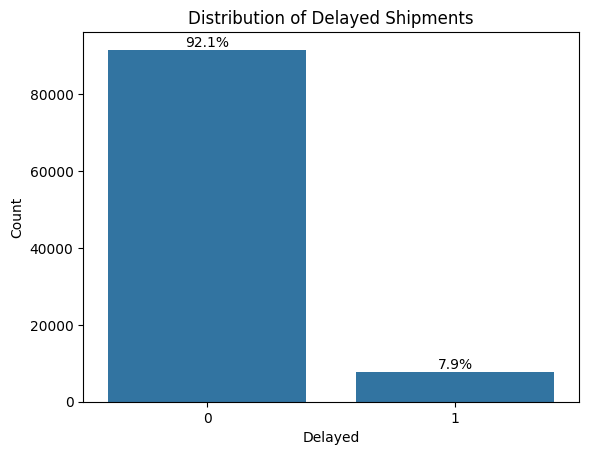

In [10]:
ax = sns.countplot(x='delayed', data=df)
total = len(df)
ax.bar_label(ax.containers[0], labels=[f'{p.get_height()/total:.1%}' for p in ax.containers[0]])
plt.title('Distribution of Delayed Shipments')
plt.xlabel('Delayed')
plt.ylabel('Count')

* 7.9% of shipments are delayed.
* Data is highly imbalanced: (Not Delayed (0): 92.1%), (Delayed (1): 7.9%)

# Data Preparation

In [12]:
# Convert the date columns to datetime objects
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_estimated_delivery_date'
]

for columns in date_columns:
    df[columns] = pd.to_datetime(df[columns])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   price                          99441 non-null  float64       
 2   freight_value                  99441 non-null  float64       
 3   payment_value                  99441 non-null  float64       
 4   payment_installments           99440 non-null  float64       
 5   product_weight_g               98650 non-null  float64       
 6   customer_state                 99441 non-null  str           
 7   seller_state                   98666 non-null  str           
 8   customer_lat                   99163 non-null  float64       
 9   customer_lng                   99163 non-null  float64       
 10  seller_lat                     98450 non-null  float64       
 11  seller_lng                

In [14]:
# Checking missing values
df.isnull().sum()

order_id                            0
price                               0
freight_value                       0
payment_value                       0
payment_installments                1
product_weight_g                  791
customer_state                      0
seller_state                      775
customer_lat                      278
customer_lng                      278
seller_lat                        991
seller_lng                        991
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_estimated_delivery_date       0
delayed                             0
dtype: int64

In [15]:
# Handling Missing Values and filling with median (robust to outliers)
df['customer_lat'] = df['customer_lat'].fillna(df['customer_lat'].median())
df['customer_lng'] = df['customer_lng'].fillna(df['customer_lng'].median())
df['seller_lat'] = df['seller_lat'].fillna(df['seller_lat'].median())
df['seller_lng'] = df['seller_lng'].fillna(df['seller_lng'].median())
df['payment_installments'] = df['payment_installments'].fillna(df['payment_installments'].median())
df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())

In [16]:
# Handling missing values for categorical columns by filling with Mode → most frequent category
df['seller_state'] = df['seller_state'].fillna(df['seller_state'].mode()[0])

In [17]:
# Missing values in order_approved_at, it means some orders were not approved yet (filling with order_purchase_timestamp)
df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])

In [18]:
df.isnull().sum()

order_id                            0
price                               0
freight_value                       0
payment_value                       0
payment_installments                0
product_weight_g                    0
customer_state                      0
seller_state                        0
customer_lat                        0
customer_lng                        0
seller_lat                          0
seller_lng                          0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date     1783
order_estimated_delivery_date       0
delayed                             0
dtype: int64

In [19]:
# Checks if order_delivered_carrier_date is missing and creates a new column 'carrier_missing' with (1 -> missing) and (0 -> not missing)
df['carrier_missing'] = df['order_delivered_carrier_date'].isna().astype(int)
df['carrier_missing'].value_counts()

carrier_missing
0    97658
1     1783
Name: count, dtype: int64

In [20]:
# Handling missing values using order_estimated_delivery_date
df['order_delivered_carrier_date'] = df['order_delivered_carrier_date'].fillna(df['order_estimated_delivery_date'])

In [21]:
df.isnull().sum()

order_id                         0
price                            0
freight_value                    0
payment_value                    0
payment_installments             0
product_weight_g                 0
customer_state                   0
seller_state                     0
customer_lat                     0
customer_lng                     0
seller_lat                       0
seller_lng                       0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_estimated_delivery_date    0
delayed                          0
carrier_missing                  0
dtype: int64

In [22]:
df.describe()

,price,freight_value,payment_value,payment_installments,product_weight_g,customer_lat,customer_lng,seller_lat,seller_lng,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,delayed,carrier_missing
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441,99441,99441,99441,99441.000000,99441.000000
mean,142.891265,23.706892,205.858013,2.930512,2092.014027,-21.196071,-46.176714,-22.800047,-47.215803,2017-12-31 08:43:12.776581,2017-12-31 19:07:21.164720,2018-01-03 23:29:23.449764,2018-01-24 03:08:37.730111,0.078710,0.017930
min,0.000000,0.000000,0.000000,0.000000,0.000000,-33.689948,-72.668881,-32.079231,-67.813284,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-09-30 00:00:00,2016-09-30 00:00:00,0.000000,0.000000
25%,45.900000,13.870000,62.760000,1.000000,300.000000,-23.588380,-48.082298,-23.611893,-48.656394,2017-09-12 14:46:19,2017-09-12 21:55:13,2017-09-14 23:13:41,2017-10-03 00:00:00,0.000000,0.000000
50%,89.000000,17.440000,109.620000,2.000000,700.000000,-22.924970,-46.630647,-23.425556,-46.743468,2018-01-18 23:04:36,2018-01-19 11:54:30,2018-01-23 20:32:30,2018-02-15 00:00:00,0.000000,0.000000
75%,152.000000,25.400000,195.910000,4.000000,1800.000000,-20.140360,-43.607441,-21.757321,-46.522287,2018-05-04 15:42:16,2018-05-04 23:50:21,2018-05-08 11:19:00,2018-05-25 00:00:00,0.000000,0.000000
max,13440.000000,1897.760000,109312.640000,24.000000,40425.000000,42.184003,-8.723762,-2.501242,-34.855616,2018-10-17 17:30:18,2018-10-17 17:30:18,2018-11-12 00:00:00,2018-11-12 00:00:00,1.000000,1.000000
std,240.560797,26.339293,619.118686,2.715673,3743.904153,5.601539,4.050465,2.737092,2.338966,NaN,NaN,NaN,NaN,0.269287,0.132699


In [23]:
# Outlier Detection using IQR method
columns = ['price', 'freight_value', 'payment_value', 'product_weight_g']

for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    print(f"{column}: {len(outliers)} outliers")

price: 8343 outliers
freight_value: 9628 outliers
payment_value: 9660 outliers
product_weight_g: 14076 outliers


In [24]:
for column in columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = df[column].clip(lower, upper)

In [25]:
df.describe()

,price,freight_value,payment_value,payment_installments,product_weight_g,customer_lat,customer_lng,seller_lat,seller_lng,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,delayed,carrier_missing
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441,99441,99441,99441,99441.000000,99441.000000
mean,113.275265,20.547508,148.081498,2.930512,1306.518723,-21.196071,-46.176714,-22.800047,-47.215803,2017-12-31 08:43:12.776581,2017-12-31 19:07:21.164720,2018-01-03 23:29:23.449764,2018-01-24 03:08:37.730111,0.078710,0.017930
min,0.000000,0.000000,0.000000,0.000000,0.000000,-33.689948,-72.668881,-32.079231,-67.813284,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-09-30 00:00:00,2016-09-30 00:00:00,0.000000,0.000000
25%,45.900000,13.870000,62.760000,1.000000,300.000000,-23.588380,-48.082298,-23.611893,-48.656394,2017-09-12 14:46:19,2017-09-12 21:55:13,2017-09-14 23:13:41,2017-10-03 00:00:00,0.000000,0.000000
50%,89.000000,17.440000,109.620000,2.000000,700.000000,-22.924970,-46.630647,-23.425556,-46.743468,2018-01-18 23:04:36,2018-01-19 11:54:30,2018-01-23 20:32:30,2018-02-15 00:00:00,0.000000,0.000000
75%,152.000000,25.400000,195.910000,4.000000,1800.000000,-20.140360,-43.607441,-21.757321,-46.522287,2018-05-04 15:42:16,2018-05-04 23:50:21,2018-05-08 11:19:00,2018-05-25 00:00:00,0.000000,0.000000
max,311.150000,42.695000,395.635000,24.000000,4050.000000,42.184003,-8.723762,-2.501242,-34.855616,2018-10-17 17:30:18,2018-10-17 17:30:18,2018-11-12 00:00:00,2018-11-12 00:00:00,1.000000,1.000000
std,88.082671,10.461681,112.535750,2.715673,1351.096019,5.601539,4.050465,2.737092,2.338966,NaN,NaN,NaN,NaN,0.269287,0.132699


In [26]:
# Dropped redundant column order_id
df.drop(columns=['order_id'], inplace=True)

# Exploratory Data Analysis

In [30]:
nums_columns = df.select_dtypes(include=['number']).columns.to_list()
cats_columns = df.select_dtypes(include=['object']).columns.to_list()

print(f"The data has {len(nums_columns)} numerical columns: {nums_columns}")
print(f"The data has {len(cats_columns)} categorical columns: {cats_columns}")

The data has 11 numerical columns: ['price', 'freight_value', 'payment_value', 'payment_installments', 'product_weight_g', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'delayed', 'carrier_missing']
The data has 2 categorical columns: ['customer_state', 'seller_state']


### Insight
* The df has 17 columns, but select_dtypes() classifies columns based on their data type, not by how many columns exist. so datetime is excluded.

In [31]:
# Define the final lists of numerical and categorical columns, and the target variable
numerical_columns = ['price', 'freight_value', 'payment_value', 'payment_installments', 'product_weight_g', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'carrier_missing']
categorical_columns = ['customer_state', 'seller_state']
target = 'delayed'

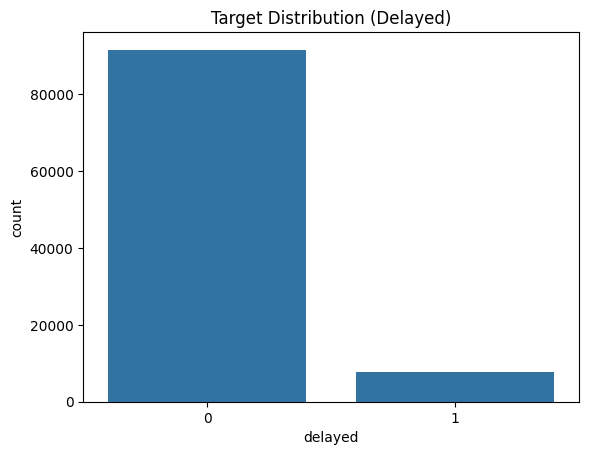

In [32]:
# Target distribution
sns.countplot(x=target, data=df)
plt.title("Target Distribution (Delayed)")
plt.show()

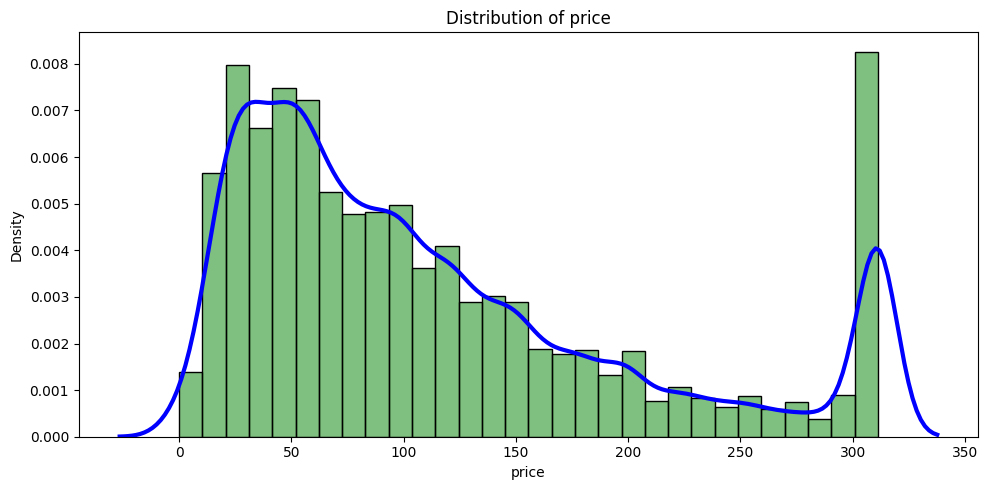

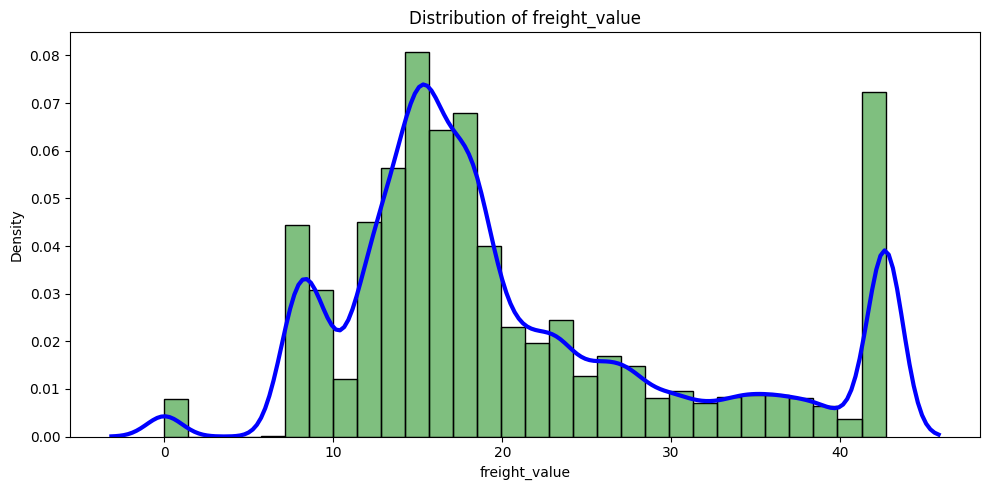

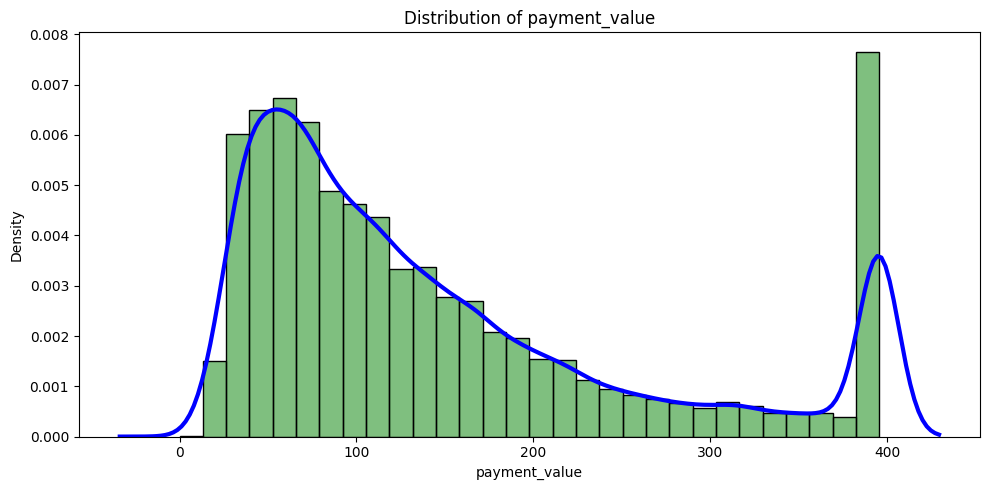

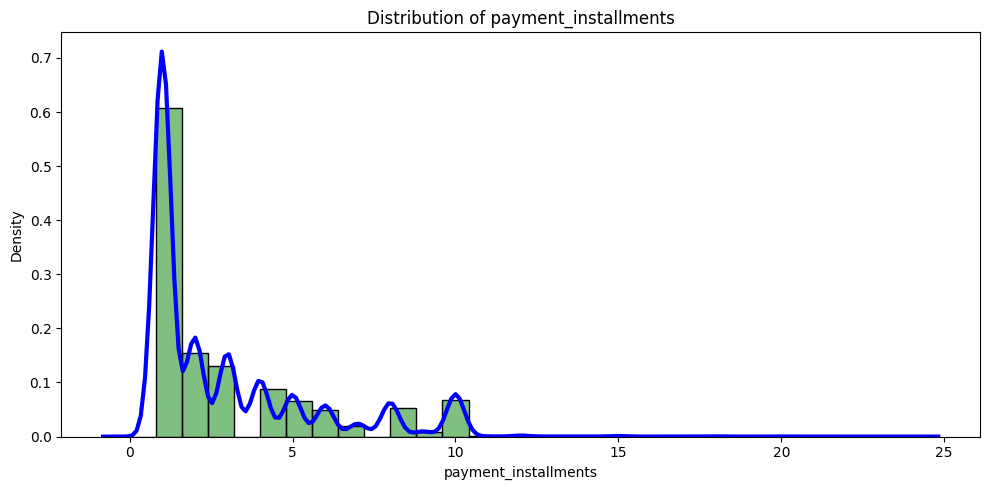

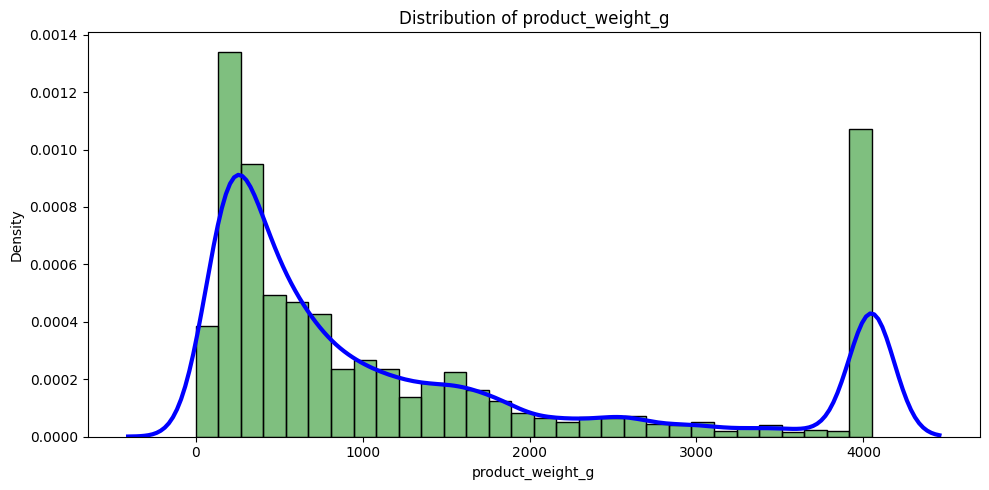

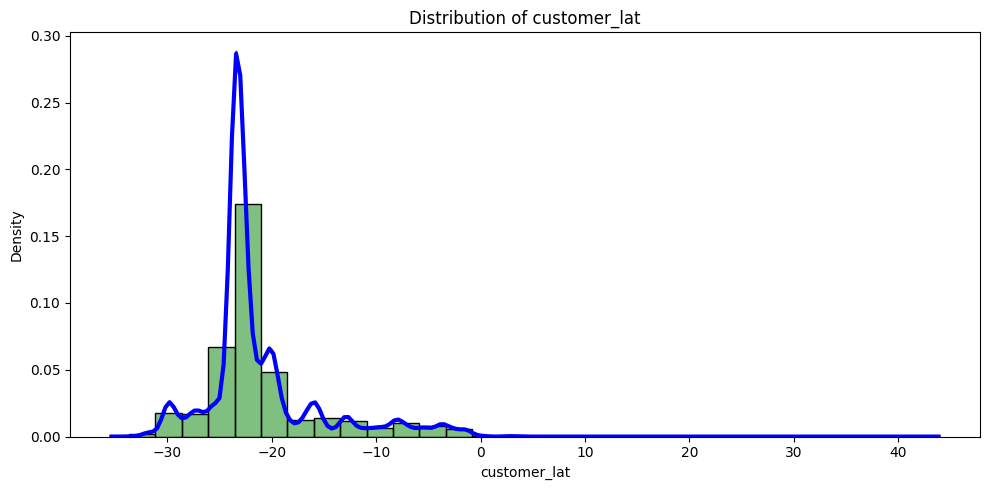

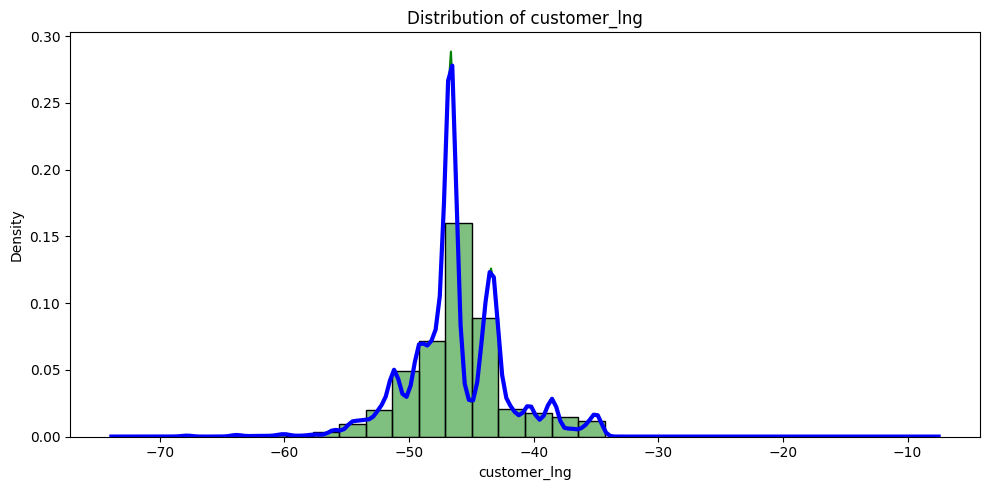

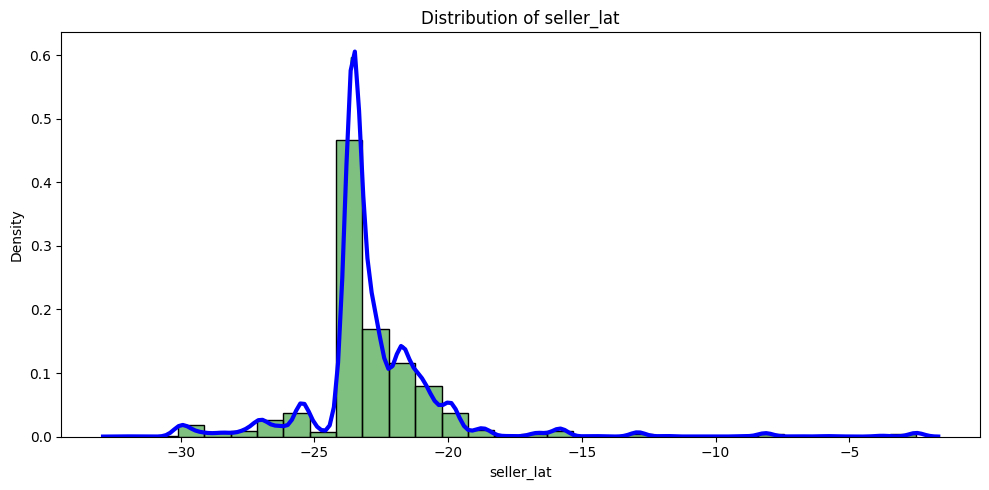

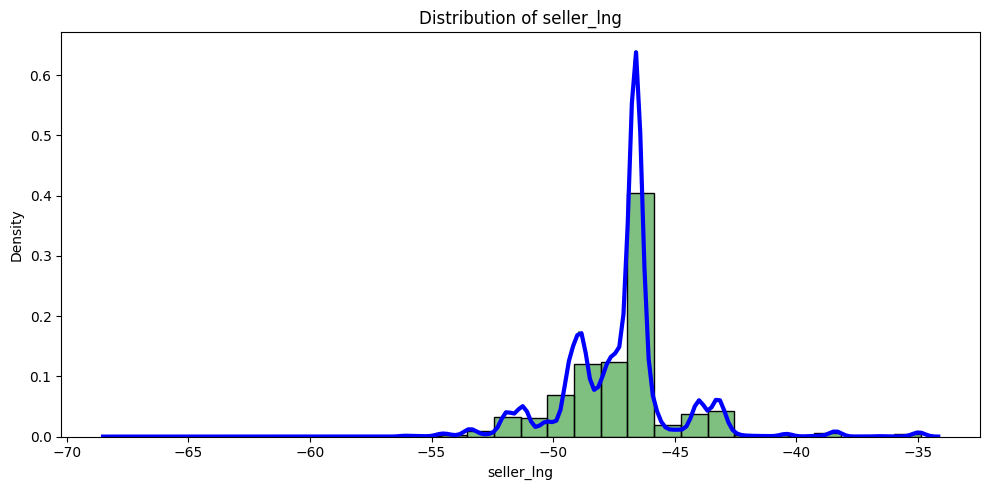

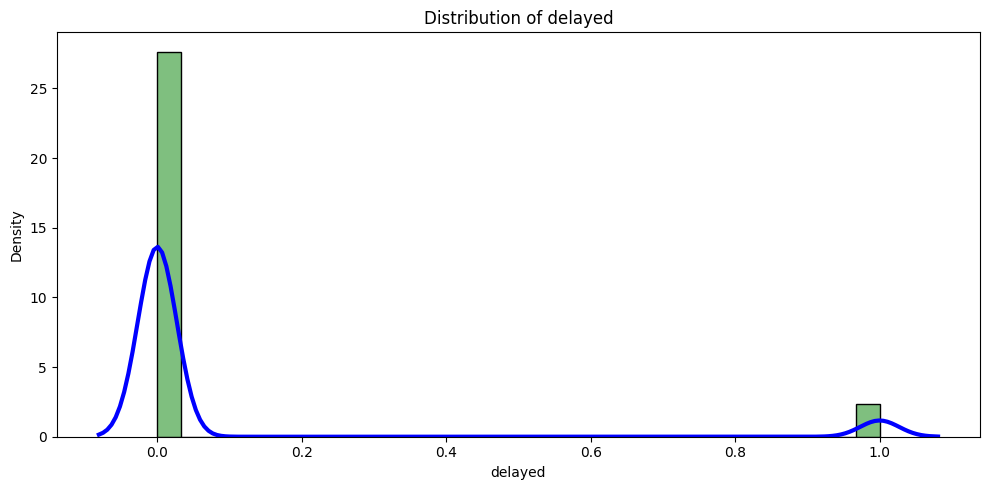

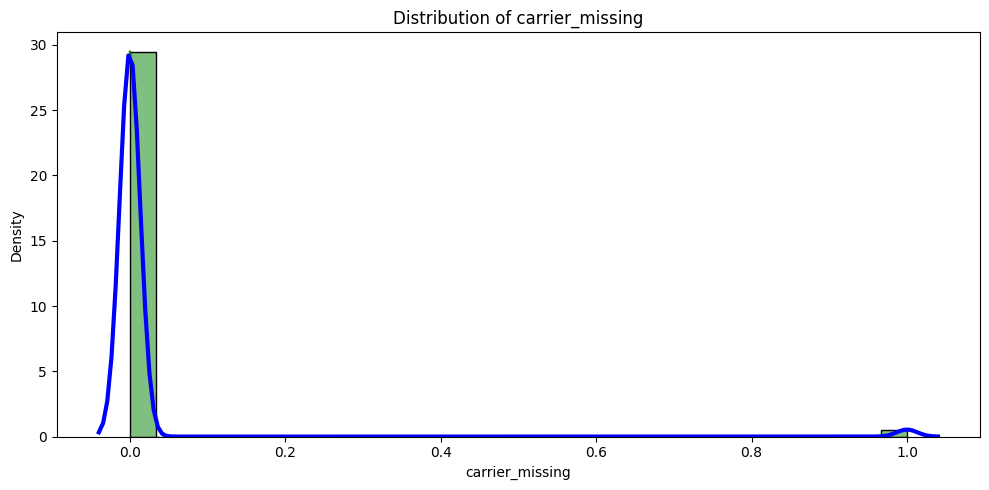

In [40]:
for column in numerical_columns:
    # Create a new figure for each column with a reasonable size for a single plot
    plt.figure(figsize=(10, 5)) 
    
    # Plot the histogram in green (using stat='density' so the KDE scales correctly)
    sns.histplot(df[column], bins=30, stat='density', kde=True, color='g')
    
    # Overlay the thicker blue KDE line
    sns.kdeplot(df[column], color='b', lw=3) 

    # Set the title and display the plot
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
    plt.show()

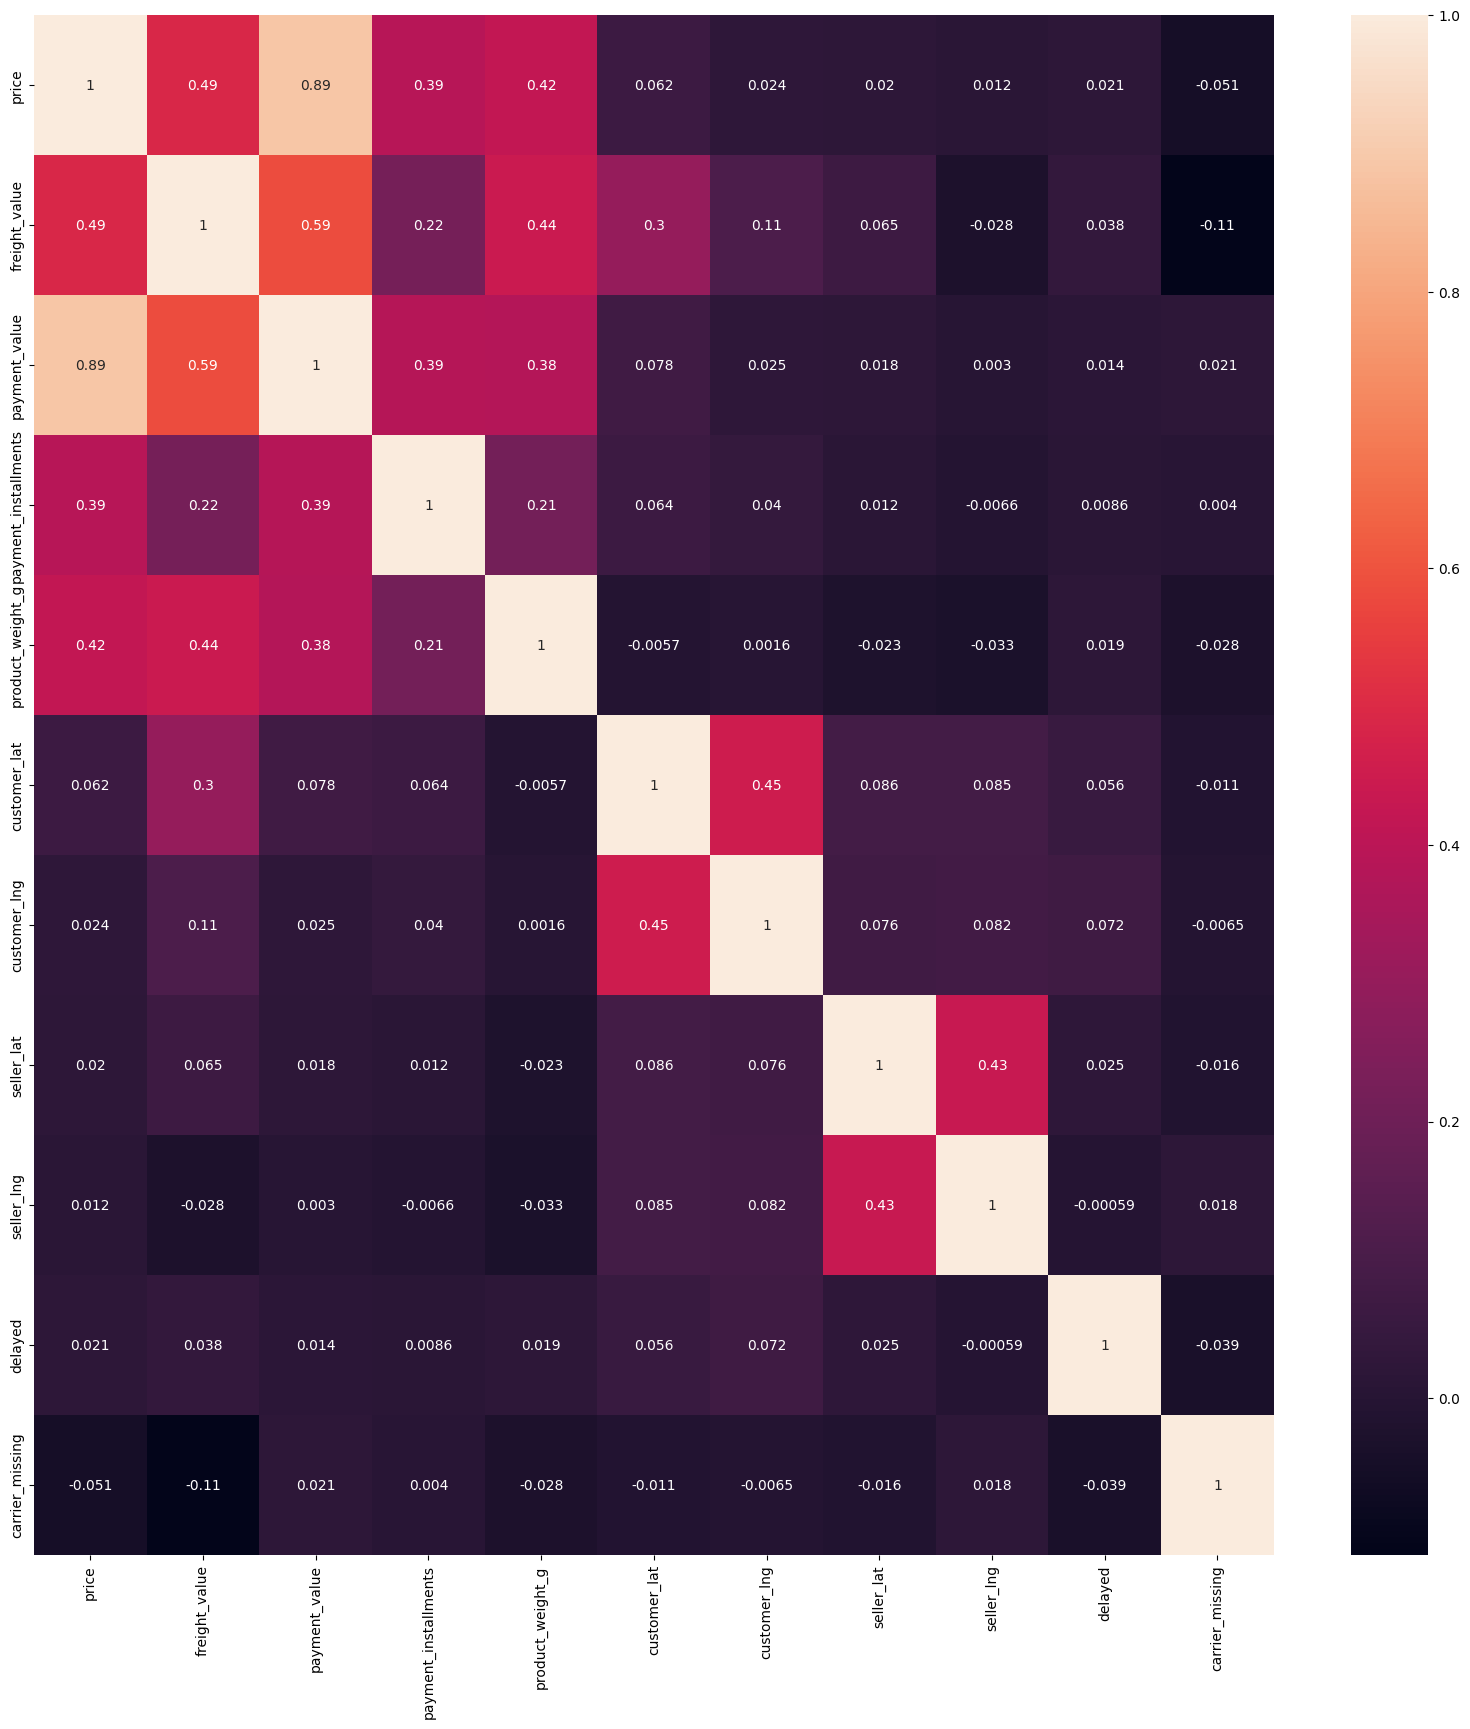

In [41]:
# Calculate correlations
numerical_columns = df.select_dtypes(include=['number'])
correlations = numerical_columns.corr()
plt.figure(figsize=(20, 20))
sns.heatmap(correlations, annot=True)
plt.show()

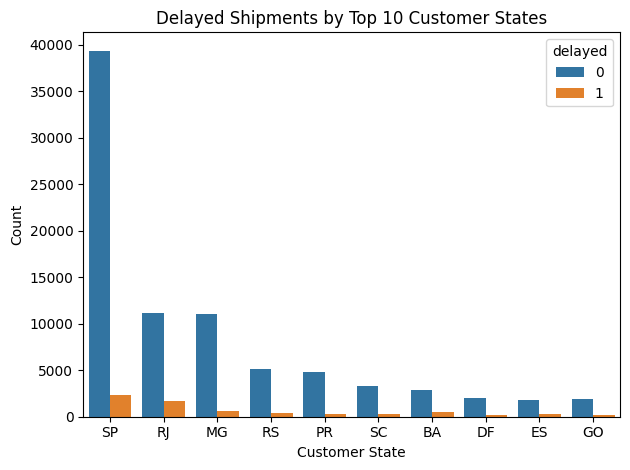

In [42]:
top_10_states = df['customer_state'].value_counts().head(10).index
sns.countplot(x='customer_state', hue='delayed', data=df, order=top_10_states)

plt.title('Delayed Shipments by Top 10 Customer States')
plt.xlabel('Customer State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

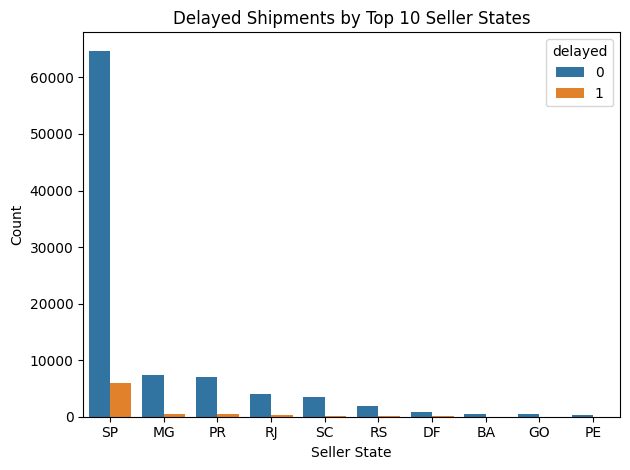

In [43]:
top_10_states = df['seller_state'].value_counts().head(10).index
sns.countplot(x='seller_state', hue='delayed', data=df, order=top_10_states)

plt.title('Delayed Shipments by Top 10 Seller States')
plt.xlabel('Seller State')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Feature Engineering

In [44]:
df.columns

Index(['price', 'freight_value', 'payment_value', 'payment_installments',
       'product_weight_g', 'customer_state', 'seller_state', 'customer_lat',
       'customer_lng', 'seller_lat', 'seller_lng', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_estimated_delivery_date', 'delayed', 'carrier_missing'],
      dtype='str')

In [45]:
# Extracting date features from order_purchase_timestamp
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
df['purchase_day'] = df['order_purchase_timestamp'].dt.day
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_weekday'] = df['order_purchase_timestamp'].dt.weekday

In [46]:
# Calculating processing time in days by subtracting order_approved_at from order_delivered_carrier_date
df['processing_time'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days

In [47]:
# Calculate estimated delivery time in days by subtracting order_purchase_timestamp from order_estimated_delivery_date
df['estimated_delivery_time'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

In [48]:
# Create a new feature 'same_state' to indicate if the customer and seller are in the same state
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

In [49]:
# Calculate the absolute difference in latitude and longitude between customer and seller
df['lat_diff'] = abs(df['customer_lat'] - df['seller_lat'])
df['lng_diff'] = abs(df['customer_lng'] - df['seller_lng'])

In [50]:
# Create a new feature 'total_cost' by adding price and freight_value
df['total_cost'] = df['price'] + df['freight_value']

In [51]:
# Create a new feature 'weight_category' by categorizing product_weight_g into bins
df['weight_category'] = pd.cut(
    df['product_weight_g'],
    bins=[0, 500, 2000, 5000, 20000],
    labels=['light', 'medium', 'heavy', 'very_heavy']
)

In [52]:
df['weight_category'].value_counts()    

weight_category
light         41692
medium        35148
heavy         22595
very_heavy        0
Name: count, dtype: int64

In [53]:
df.columns

Index(['price', 'freight_value', 'payment_value', 'payment_installments',
       'product_weight_g', 'customer_state', 'seller_state', 'customer_lat',
       'customer_lng', 'seller_lat', 'seller_lng', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_estimated_delivery_date', 'delayed', 'carrier_missing',
       'purchase_hour', 'purchase_day', 'purchase_month', 'purchase_weekday',
       'processing_time', 'estimated_delivery_time', 'same_state', 'lat_diff',
       'lng_diff', 'total_cost', 'weight_category'],
      dtype='str')

In [54]:
df.isnull().sum()

price                            0
freight_value                    0
payment_value                    0
payment_installments             0
product_weight_g                 0
customer_state                   0
seller_state                     0
customer_lat                     0
customer_lng                     0
seller_lat                       0
seller_lng                       0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_estimated_delivery_date    0
delayed                          0
carrier_missing                  0
purchase_hour                    0
purchase_day                     0
purchase_month                   0
purchase_weekday                 0
processing_time                  0
estimated_delivery_time          0
same_state                       0
lat_diff                         0
lng_diff                         0
total_cost                       0
weight_category                  6
dtype: int64

In [55]:
# Fill missing values in weight_category with the mode (most frequent category)
df['weight_category'] = df['weight_category'].fillna(df['weight_category'].mode()[0])

In [56]:
df.isnull().sum()

price                            0
freight_value                    0
payment_value                    0
payment_installments             0
product_weight_g                 0
customer_state                   0
seller_state                     0
customer_lat                     0
customer_lng                     0
seller_lat                       0
seller_lng                       0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_estimated_delivery_date    0
delayed                          0
carrier_missing                  0
purchase_hour                    0
purchase_day                     0
purchase_month                   0
purchase_weekday                 0
processing_time                  0
estimated_delivery_time          0
same_state                       0
lat_diff                         0
lng_diff                         0
total_cost                       0
weight_category                  0
dtype: int64

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   price                          99441 non-null  float64       
 1   freight_value                  99441 non-null  float64       
 2   payment_value                  99441 non-null  float64       
 3   payment_installments           99441 non-null  float64       
 4   product_weight_g               99441 non-null  float64       
 5   customer_state                 99441 non-null  str           
 6   seller_state                   99441 non-null  str           
 7   customer_lat                   99441 non-null  float64       
 8   customer_lng                   99441 non-null  float64       
 9   seller_lat                     99441 non-null  float64       
 10  seller_lng                     99441 non-null  float64       
 11  order_purchase_timestamp  

In [58]:
new_df = df.to_csv('../data/processed_data.csv', index=False)